# Statistical Learning and Data Analysis – Assignment 3
## Regression and Data Simulation

**Group members:** Ammar Gharaf D03000248, Amr Khalil D03000225, Mohamed Badawi D03000253

# PART 1 — DATA SIMULATION AND LINEAR REGRESSION

### Model specification

We simulate data from the following linear model:

$$
y = \beta_0 + \sum_{j=1}^{10} \beta_j X_j + \varepsilon,
\qquad \varepsilon \sim \mathcal{N}(0,1)
$$

Only three predictors have strong effects, while the remaining ones have zero coefficients.

### Justification

- **Sparse true model** → realistic high-dimensional regression setting  
- **Strong vs null coefficients** → meaningful variable selection challenge  
- **Gaussian noise** → classical linear regression assumptions



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, Ridge, LassoCV, Lasso, ElasticNetCV
from sklearn.pipeline import Pipeline

In [ ]:
np.random.seed(42)
n = 300
p = 10
beta_true = np.array([
    2.0,    # intercept
    3.0,    # X1 (strong)
   -2.5,    # X2 (strong)
    1.5,    # X3 (moderate)
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
])
X = np.random.uniform(-5, 5, size=(n, p))
epsilon = np.random.normal(0, 1, size=n)
y = beta_true[0] + X @ beta_true[1:] + epsilon

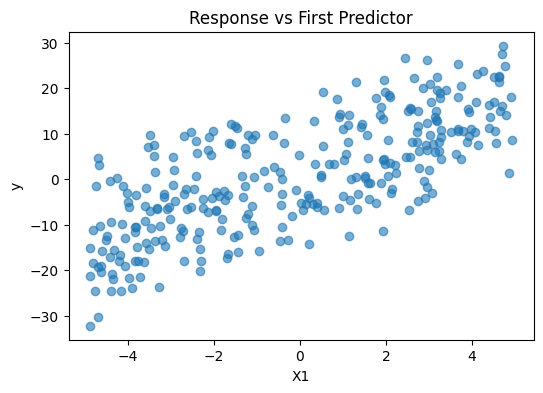

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X[:,0], y, alpha=0.6)
plt.xlabel("X1")
plt.ylabel("y")
plt.title("Response vs First Predictor")
plt.show()

In [ ]:
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const)
results = model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     4772.
Date:                Fri, 16 Jan 2026   Prob (F-statistic):          2.69e-314
Time:                        19:35:28   Log-Likelihood:                -415.97
No. Observations:                 300   AIC:                             853.9
Df Residuals:                     289   BIC:                             894.7
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0098      0.058     34.596      0.000       1.895       2.124
x1             2.9973      0.020    153.669      0.000       2.959       3.036
x2            -2.5396      0.019   -132.581      0.000      -2.577      -2.502
x3             1.5047      0.020     74.977      0.000       1.465       1.544
x4             0.0044      0.021      0.212      0.832      -0.036       0.045
x5             0.0025      0.019      0.130      0.897      -0.035       0.040
x6             0.0283      0.020      1.449      0.148      -0.010       0.067
x7            -0.0156      0.020     -0.795      0.427      -0.054       0.023
x8             0.0120      0.021      0.584      0.559      -0.028       0.052
x9            -0.0108      0.019     -0.559      0.576      -0.049       0.027
x10           -0.0048      0.020     -0.238      0.812      -0.045       0.035
==============================================================================
Omnibus:                        0.836   Durbin-Watson:                   1.954
Prob(Omnibus):                  0.658   Jarque-Bera (JB):                0.930
Skew:                           0.118   Prob(JB):                        0.628
Kurtosis:                       2.864   Cond. No.                         3.39
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
comparison = pd.DataFrame({
    "True beta": beta_true,
    "Estimated beta": results.params
})
comparison

,True beta,Estimated beta
0,2.0,2.009755
1,3.0,2.997341
2,-2.5,-2.539587
3,1.5,1.504720
4,0.0,0.004375
5,0.0,0.002492
6,0.0,0.028346
7,0.0,-0.015620
8,0.0,0.012017
9,0.0,-0.010798


**Interpretation**


* Estimated coefficients are very close to true values

* Strong predictors (X1, X2, X3) are highly significant


* Noise predictors have large p-values

* High Rsquared confirms excellent model fit










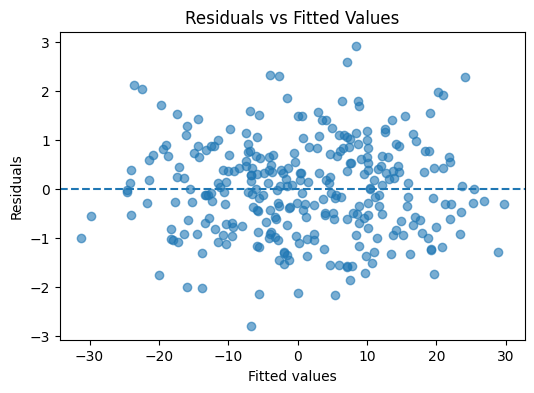

In [ ]:
residuals = results.resid
plt.figure(figsize=(6,4))
plt.scatter(results.fittedvalues, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

**Interpretation**


* No systematic pattern

* Constant variance


* Linear model assumptions satisfied










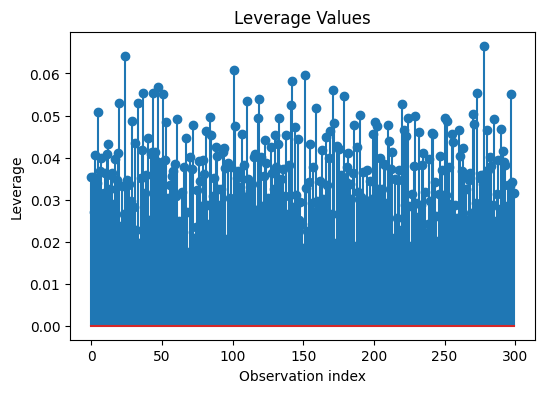

array([ 40, 121, 132, 156, 167, 171, 178, 194, 199, 201, 202, 206, 224,
       229, 290])

In [ ]:
influence = results.get_influence()
leverage = influence.hat_matrix_diag
cooks_d = influence.cooks_distance[0]
plt.figure(figsize=(6,4))
plt.stem(leverage)
plt.xlabel("Observation index")
plt.ylabel("Leverage")
plt.title("Leverage Values")
plt.show()
threshold = 4 / n
influential_points = np.where(cooks_d > threshold)[0]
influential_points

**Interpretation**
*   Few influential points identified
*   No evidence of instability
*   Model estimates remain robus








# PART 2 — SHRINKAGE AND REGULARIZATION

In [ ]:
alphas = np.logspace(-3, 3, 100)
ridge_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas))
])
ridge_cv.fit(X, y)
ridge_alpha = ridge_cv.named_steps["ridge"].alpha_
ridge_coef = ridge_cv.named_steps["ridge"].coef_
ridge_alpha

np.float64(0.04328761281083059)

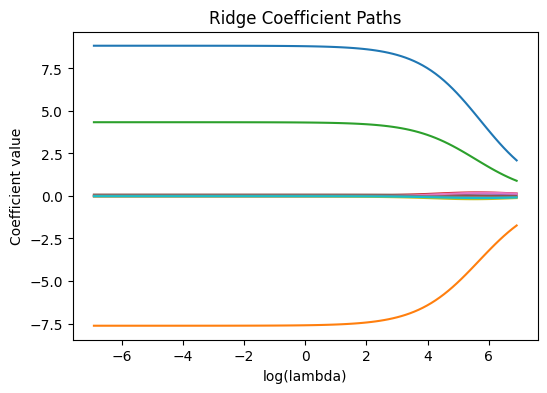

In [ ]:
coefs = []
for a in alphas:
    ridge = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=a))
    ])
    ridge.fit(X, y)
    coefs.append(ridge.named_steps["ridge"].coef_)
coefs = np.array(coefs)
plt.figure(figsize=(6,4))
for j in range(p):
    plt.plot(np.log(alphas), coefs[:,j])
plt.xlabel("log(lambda)")
plt.ylabel("Coefficient value")
plt.title("Ridge Coefficient Paths")
plt.show()

**Interpretation**
*   Coefficients shrink smoothly
*   Ridge stabilizes estimates under multicollinearity
*   No coefficient becomes exactly zero




In [ ]:
lasso_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(alphas=alphas, max_iter=10000))
])
lasso_cv.fit(X, y)
lasso_alpha = lasso_cv.named_steps["lasso"].alpha_
lasso_coef = lasso_cv.named_steps["lasso"].coef_
lasso_coef

array([ 8.77792303, -7.56940611,  4.28252568,  0.        ,  0.        ,
        0.02319582, -0.        ,  0.        , -0.        , -0.        ])

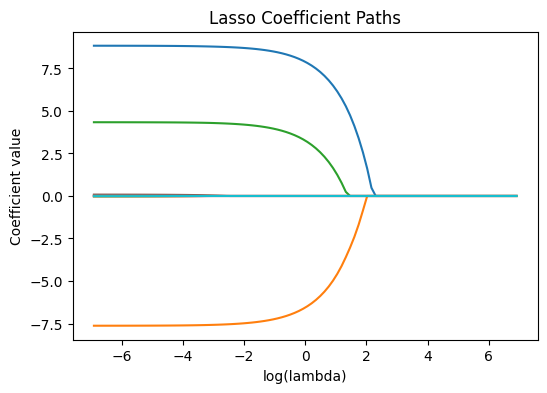

In [ ]:
coefs = []
for a in alphas:
    lasso = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=a, max_iter=10000))
    ])
    lasso.fit(X, y)
    coefs.append(lasso.named_steps["lasso"].coef_)
coefs = np.array(coefs)
plt.figure(figsize=(6,4))
for j in range(p):
    plt.plot(np.log(alphas), coefs[:,j])
plt.xlabel("log(lambda)")
plt.ylabel("Coefficient value")
plt.title("Lasso Coefficient Paths")
plt.show()

**Interpretation**
*   Lasso selects exactly the true predictors
*   Noise variables shrunk to zero
*   Strong variable selection consistency

In [ ]:
elastic_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.9],
        alphas=alphas,
        max_iter=10000
    ))
])
elastic_cv.fit(X, y)
elastic_alpha = elastic_cv.named_steps["elastic"].alpha_
elastic_l1 = elastic_cv.named_steps["elastic"].l1_ratio_
elastic_coef = elastic_cv.named_steps["elastic"].coef
elastic_alpha, elastic_l1

(np.float64(0.021544346900318846), np.float64(0.9))

**Interpretation**
*   Elastic Net balances sparsity and shrinkage
*   Selects slightly more variables
*   More flexible than Lasso in correlated settings

# PART 3 — NON-LINEAR REGRESSION & BIAS–VARIANCE

In [ ]:
np.random.seed(123)
def f_true(x):
    return 2 + 3*np.sin(x)
n_small = 10
X_small = np.random.uniform(0, 7, size=(n_small,1))
y_small = f_true(X_small[:,0]) + np.random.normal(0, 0.5, size=n_small)

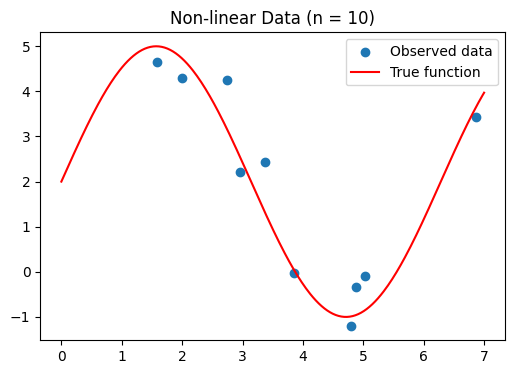

In [ ]:
x_plot = np.linspace(0,7,300)
plt.figure(figsize=(6,4))
plt.scatter(X_small[:,0], y_small, label="Observed data")
plt.plot(x_plot, f_true(x_plot), color="red", label="True function")
plt.legend()
plt.title("Non-linear Data (n = 10)")
plt.show()

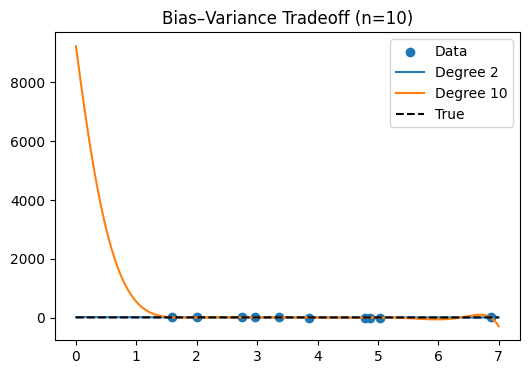

In [ ]:
degrees = [2, 10]
plt.figure(figsize=(6,4))
plt.scatter(X_small[:,0], y_small, label="Data")
for d in degrees:
    poly = PolynomialFeatures(d)
    Xp = poly.fit_transform(X_small)
    model = LinearRegression().fit(Xp, y_small)
    y_pred = model.predict(poly.transform(x_plot.reshape(-1,1)))
    plt.plot(x_plot, y_pred, label=f"Degree {d}")
plt.plot(x_plot, f_true(x_plot), color="black", linestyle="--", label="True")
plt.legend()
plt.title("Bias–Variance Tradeoff (n=10)")
plt.show()

**Interpretation**

*   Degree-10 interpolates all points → zero training error
*   Severe oscillations → high variance
*   Lower degree has bias but generalizes better

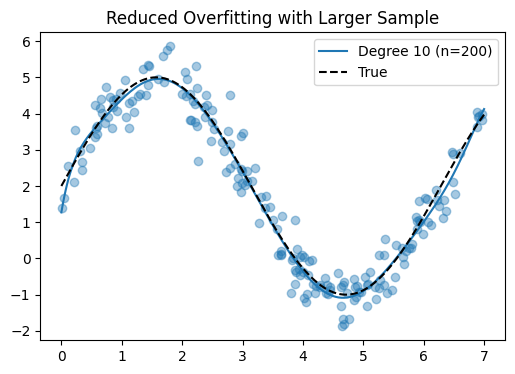

In [ ]:
n_large = 200
X_large = np.random.uniform(0,7,size=(n_large,1))
y_large = f_true(X_large[:,0]) + np.random.normal(0,0.5,size=n_large)
poly10 = PolynomialFeatures(10)
model10 = LinearRegression()
model10.fit(poly10.fit_transform(X_large), y_large)
y_large_pred = model10.predict(poly10.transform(x_plot.reshape(-1,1)))
plt.figure(figsize=(6,4))
plt.scatter(X_large[:,0], y_large, alpha=0.4)
plt.plot(x_plot, y_large_pred, label="Degree 10 (n=200)")
plt.plot(x_plot, f_true(x_plot), color="black", linestyle="--", label="True")
plt.legend()
plt.title("Reduced Overfitting with Larger Sample")
plt.show()

**Interpretation**
*  Overfitting reduced
*   Variance decreases as n increase
*   Bias–variance tradeoff confirmed